In [1]:
!pip install ultralytics roboflow pandas matplotlib seaborn

import os
import yaml
import torch
import gc
import shutil
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob
from roboflow import Roboflow
from ultralytics import YOLO

print("Môi trường đã sẵn sàng!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 43.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.9/207.9 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 34.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 57.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 75.2 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependenc

In [2]:
# Tải dữ liệu
rf = Roboflow(api_key="zau700BeI9He3qiUGWgF")
project = rf.workspace("capstone-kvhat").project("traffic-wy5ag")
version = project.version(1)
dataset = version.download("yolov8")

# 1. Sửa file data.yaml
data_yaml_path = f"{dataset.location}/data.yaml"
with open(data_yaml_path, 'r') as f:
    data_cfg = yaml.safe_load(f)

data_cfg['names'] = {0: 'vehicle'} # Đặt tên chung
data_cfg['nc'] = 1                 # Số lượng lớp = 1
with open(data_yaml_path, 'w') as f:
    yaml.dump(data_cfg, f)

# 2. Sửa các file nhãn .txt (Ép ID về 0)
label_files = glob(f"{dataset.location}/*/labels/*.txt")
for file_path in label_files:
    with open(file_path, 'r') as f:
        lines = f.readlines()
    new_lines = [ "0 " + " ".join(line.split()[1:]) + "\n" for line in lines if len(line.split()) > 0]
    with open(file_path, 'w') as f:
        f.writelines(new_lines)

print("✅ Đã chuyển đổi Dataset sang bài toán nhận diện 1 lớp (Vehicle Detection).")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to traffic-1 in yolov8:: 100%|██████████| 576/576 [00:00<00:00, 7138.78it/s]

✅ Đã chuyển đổi Dataset sang bài toán nhận diện 1 lớp (Vehicle Detection).


In [3]:
# Danh sách 5 mô hình đặc trưng
model_list = [
    {"name": "1_YOLOv8n_Baseline", "weights": "yolov8n.pt"},
    {"name": "2_YOLOv10n_Efficiency", "weights": "yolov10n.pt"},
    {"name": "3_YOLOv11n_Latest", "weights": "yolo11n.pt"},
    {"name": "4_YOLOv9c_Complex", "weights": "yolov9c.pt"},
    {"name": "5_RTDETR_Hybrid", "weights": "rtdetr-l.pt"}
]

results_dict = {}

for m in model_list:
    print(f"\n🚀 Đang huấn luyện mô hình: {m['name']}")
    model = YOLO(m['weights'])
    
    # Huấn luyện
    results = model.train(
        data=data_yaml_path,
        epochs=30,
        imgsz=640,
        name=m['name'],
        exist_ok=True,
        verbose=False
    )
    
    # Lưu chỉ số mAP
    results_dict[m['name']] = results.results_dict['metrics/mAP50(B)']
    
    # Dọn dẹp bộ nhớ GPU
    del model
    torch.cuda.empty_cache()
    gc.collect()

print("\n Hoàn thành huấn luyện 5 mô hình!")


🚀 Đang huấn luyện mô hình: 1_YOLOv8n_Baseline
Ultralytics 8.4.49 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/traffic-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=1_YOLOv8n_Baseline, nbs=64, nms=False, opset=None,

grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)


       1/30      12.5G      1.163     0.7387     0.4027        200        640: 100% ━━━━━━━━━━━━ 13/13 1.9s/it 24.6s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 2.5s/it 4.9s
                   all         56       1321      0.448      0.694      0.526      0.366

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size


grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)


       2/30      12.1G     0.5528     0.5169     0.1343        131        640: 100% ━━━━━━━━━━━━ 13/13 1.2s/it 15.5s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 1.6it/s 1.3s
                   all         56       1321      0.621       0.73      0.701        0.5

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size


...

      28/30      11.8G     0.2434     0.3857      0.061        153        640: 100% ━━━━━━━━━━━━ 13/13 1.1s/it 14.4s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 1.7it/s 1.2s
                   all         56       1321       0.75      0.836      0.848      0.672

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size


grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)


      29/30      11.8G     0.2403     0.3762    0.05987        106        640: 100% ━━━━━━━━━━━━ 13/13 1.1s/it 14.3s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 1.6it/s 1.2s
                   all         56       1321      0.755      0.824      0.845      0.668

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size


grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)


      30/30      12.3G     0.2459     0.3773    0.05879         72        640: 100% ━━━━━━━━━━━━ 13/13 1.1s/it 14.4s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 1.6it/s 1.2s
                   all         56       1321      0.757       0.83      0.846      0.667

30 epochs completed in 0.153 hours.
Optimizer stripped from /kaggle/working/runs/detect/5_RTDETR_Hybrid/weights/last.pt, 66.2MB
Optimizer stripped from /kaggle/working/runs/detect/5_RTDETR_Hybrid/weights/best.pt, 66.2MB

Validating /kaggle/working/runs/detect/5_RTDETR_Hybrid/weights/best.pt...
Ultralytics 8.4.49 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
rt-detr-l summary: 310 layers, 31,985,795 parameters, 0 gradients, 103.4 GFLOPs
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 1.4s/it 2.9s
                   all         56       1321       0.75      0.836      0.849      0.

--- BẢNG KẾT QUẢ SO SÁNH ---


,Mô hình,mAP50
0,1_YOLOv8n_Baseline,0.853479
1,2_YOLOv10n_Efficiency,0.758242
2,3_YOLOv11n_Latest,0.848248
3,4_YOLOv9c_Complex,0.877614
4,5_RTDETR_Hybrid,0.848594




Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



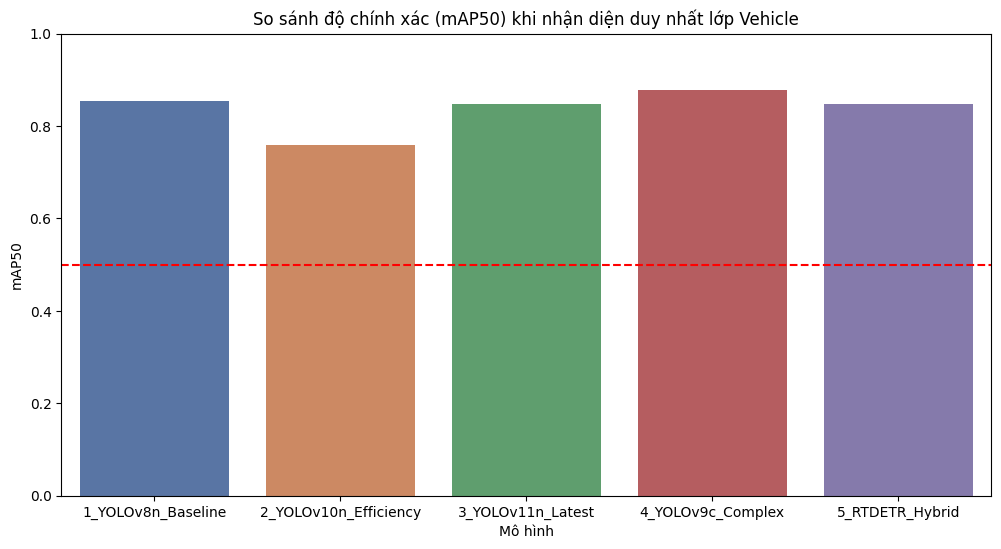

In [4]:
# Tạo DataFrame so sánh
df_compare = pd.DataFrame(list(results_dict.items()), columns=['Mô hình', 'mAP50'])

print("--- BẢNG KẾT QUẢ SO SÁNH ---")
display(df_compare)

# Vẽ biểu đồ
plt.figure(figsize=(12, 6))
sns.barplot(data=df_compare, x='Mô hình', y='mAP50', palette='deep')
plt.axhline(0.5, color='red', linestyle='--') # Mốc 50%
plt.title("So sánh độ chính xác (mAP50) khi nhận diện duy nhất lớp Vehicle")
plt.ylim(0, 1)
plt.show()

In [5]:
shutil.make_archive('vehicle_detection_final_results', 'zip', 'runs/detect')
print("✅ Đã nén xong! Hãy tải file 'vehicle_detection_final_results.zip' trong mục Output.")

✅ Đã nén xong! Hãy tải file 'vehicle_detection_final_results.zip' trong mục Output.
